# 02 — Forecasting

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_PATH = Path("../data/raw/GlobalWeatherRepository.csv")
TARGET_CITY = "Kyiv"
TARGET_COL = "temperature_celsius"

df = pd.read_csv(DATA_PATH)
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
df = df.drop_duplicates(subset=["location_name", "last_updated"], keep="first")

city_df = (
    df.loc[df["location_name"] == TARGET_CITY, ["last_updated", TARGET_COL]]
    .sort_values("last_updated")
    .reset_index(drop=True)
)

city_df.shape

(863, 2)

In [2]:
n = len(city_df)
split_idx = int(n * 0.8)

train_df = city_df.iloc[:split_idx].copy()
test_df = city_df.iloc[split_idx:].copy()

print("train:", train_df["last_updated"].min(), "→", train_df["last_updated"].max())
print("test: ", test_df["last_updated"].min(), "→", test_df["last_updated"].max())
print(len(train_df), len(test_df))

train: 2024-05-16 11:45:00 → 2026-04-07 09:30:00
test:  2026-04-08 09:45:00 → 2026-09-27 08:45:00
690 173


In [3]:
def eval_forecast(y_true, y_pred, name: str):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE={mae:.3f}°C, RMSE={rmse:.3f}°C")
    return mae, rmse

In [4]:
y_train = train_df[TARGET_COL].to_numpy()
y_test = test_df[TARGET_COL].to_numpy()

pred_naive = []
history = y_train.tolist()
for actual in y_test:
    pred_naive.append(history[-1])
    history.append(actual)

pred_naive = np.array(pred_naive)
eval_forecast(y_test, pred_naive, "Naive (last value)")

Naive (last value): MAE=2.509°C, RMSE=3.753°C


(2.509248554913295, np.float64(3.753387679835978))

In [5]:
series = city_df[TARGET_COL].to_numpy()
pred_seasonal = []
for i in range(split_idx, n):
    lag = 365
    if i - lag >= 0:
        pred_seasonal.append(series[i - lag])
    else:
        pred_seasonal.append(series[i - 1])  # fallback if not enough history

pred_seasonal = np.array(pred_seasonal)
eval_forecast(y_test, pred_seasonal, "Seasonal naive (lag 365)")

Seasonal naive (lag 365): MAE=5.993°C, RMSE=7.528°C


(5.993063583815028, np.float64(7.528450853551165))

In [6]:
# Calendar alignment of the 365-row lag on the test window
lag_days = (
    city_df["last_updated"].iloc[split_idx:].values
    - city_df["last_updated"].iloc[split_idx - 365 : n - 365].values
) / np.timedelta64(1, "D")
print(
    f"365-row lag spans {lag_days.min():.2f}–{lag_days.max():.2f} days on holdout"
)


365-row lag spans 365.83–365.93 days on holdout


**Why seasonal naive loses:** the 365-row lag lands within ~1 day of the same calendar date (see print above), so mis-timed calendar alignment is *not* the main failure mode. Last year's weather on that date differs from today by ordinary variability, while persistence uses yesterday. Kyiv's observation hour also drifted (afternoon ≈15–17h in 2024 → morning ≈9h in 2026), adding time-of-day bias to year-over-year comparisons.


In [7]:
LAGS = [1, 2, 3, 7, 14, 28]

def make_lag_matrix(values, lags):
    X, y = [], []
    max_lag = max(lags)
    for i in range(max_lag, len(values)):
        X.append([values[i - lag] for lag in lags])
        y.append(values[i])
    return np.array(X), np.array(y)

train_values = train_df[TARGET_COL].to_numpy()
X_train, y_train_ml = make_lag_matrix(train_values, LAGS)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train_ml) 

history = train_values.tolist()
pred_ridge = []
for actual in y_test:
    feats = np.array([[history[-lag] for lag in LAGS]])
    pred = model.predict(feats)[0]
    pred_ridge.append(pred)
    history.append(actual)

pred_ridge = np.array(pred_ridge)
eval_forecast(y_test, pred_ridge, "Ridge (lags)")

Ridge (lags): MAE=2.474°C, RMSE=3.599°C


(2.4744812824296463, np.float64(3.598768400746367))

In [8]:
results = pd.DataFrame({
    "naive": pred_naive,
    "seasonal_365": pred_seasonal,
    "ridge": pred_ridge,
}, index=test_df["last_updated"])

maes = {col: mean_absolute_error(y_test, results[col]) for col in results.columns}
best_two = sorted(maes, key=maes.get)[:2]
print("MAE by model:", maes)
print("Best two:", best_two)

pred_ensemble = results[best_two].mean(axis=1).to_numpy()
eval_forecast(y_test, pred_ensemble, f"Ensemble (mean of {best_two})")

MAE by model: {'naive': 2.509248554913295, 'seasonal_365': 5.993063583815028, 'ridge': 2.4744812824296463}
Best two: ['ridge', 'naive']
Ensemble (mean of ['ridge', 'naive']): MAE=2.474°C, RMSE=3.653°C


(2.4738270752242353, np.float64(3.6525374893043674))

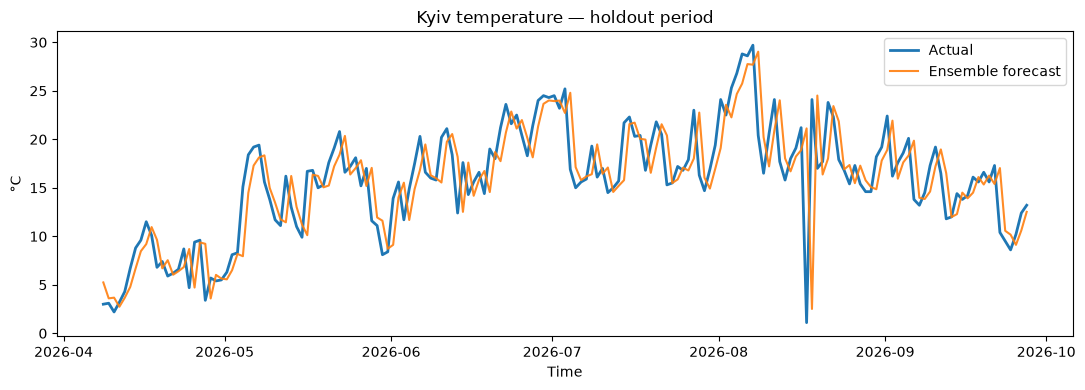

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(test_df["last_updated"], y_test, label="Actual", linewidth=2)
plt.plot(test_df["last_updated"], pred_ensemble, label="Ensemble forecast", alpha=0.9)
plt.title(f"{TARGET_CITY} temperature — holdout period")
plt.xlabel("Time")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/kyiv_forecast_holdout.png", dpi=150)
plt.show()